# Time shift between SIR and BSI

- Uniform filter, convolution with the SIR result

In [24]:
import os
os.getcwd()
os.chdir('/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli/')

In [76]:
!cp grid/grid_params/final_yearly_bsi/grid_params_A_I0.py grid/grid_params.py

In [ ]:
!python3 grid/run_grid.py

/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
Using real data. Dataset: NORM, clade: A
Iter: 0
Iter: 1000
Iter: 2000
Iter: 3000
Iter: 4000
Iter: 5000
Iter: 6000
Iter: 7000
Iter: 8000
Iter: 9000
Iter: 10000
Iter: 11000
Iter: 12000
Iter: 13000
Iter: 14000
Iter: 15000
Iter: 16000
Iter: 17000
Iter: 18000
Iter: 19000
Iter: 20000
Iter: 21000
Iter: 22000
Iter: 23000
Iter: 24000
Iter: 25000
Iter: 26000
Iter: 27000
Iter: 28000
Iter: 29000
Iter: 30000
Iter: 31000
Iter: 32000


In [72]:
from cluster.scripts.load_data import *
clade = "A"
is_prop = True
pop_size = 1000000
bsi_obs = get_incidence_data("data/NORM_incidence.csv", clade = clade, is_prop = is_prop, n_incidence_pop = pop_size)

theta_bsi_a_0 = bsi_obs.iloc[0]
theta_bsi_a_0

3.8954810986455e-06

In [73]:
type(bsi_obs)
bsi_obs.values.iloc[0]

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

Results to visualize: res/sim_res/obs_NORM_A_I0_2023-09-14_09-06-36/sim_params.txt
Year
2004    3.895481e-06
2005    3.949891e-10
2006    1.263574e-05
2007    4.214390e-06
2008    1.053623e-05
2009    5.791327e-06
2010    1.535184e-05
2011    8.640565e-06
2012    2.363202e-05
2013    3.185117e-05
2014    3.004447e-05
2015    1.012509e-05
2016    2.025119e-05
2017    2.130096e-05
Name: A, dtype: float64


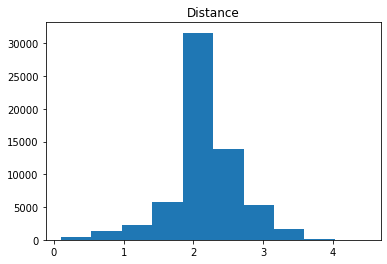

Beta mean: 0.025480681687903683
Gamma mean: 0.01554171911526704
R = mean(beta/gamma): 2.0022141169653738
R = median(beta/gamma): 1.6963951807228914


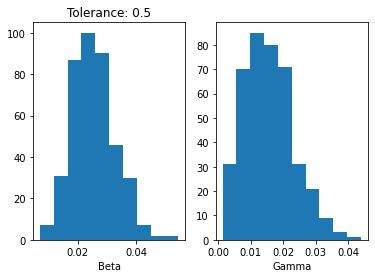

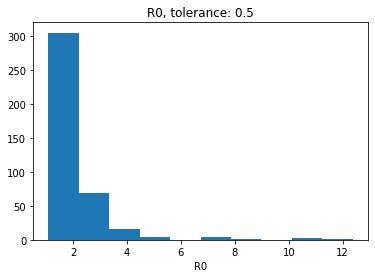

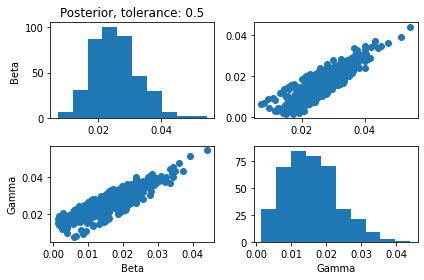

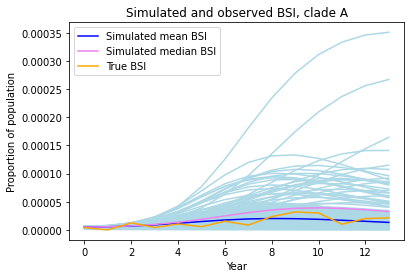

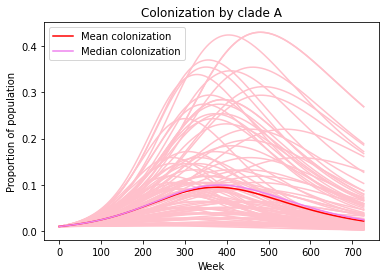

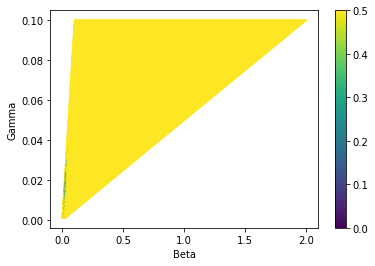

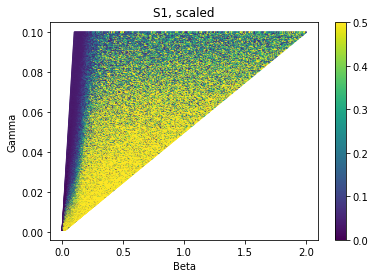

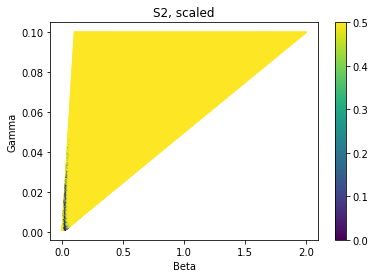

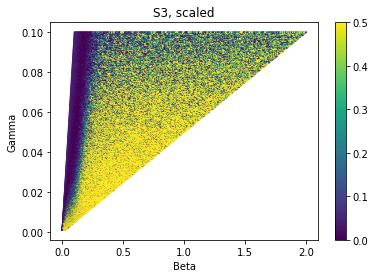

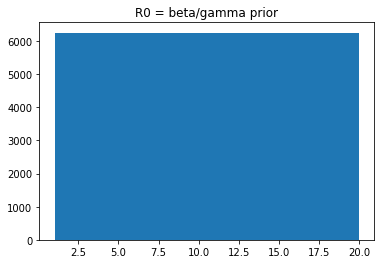

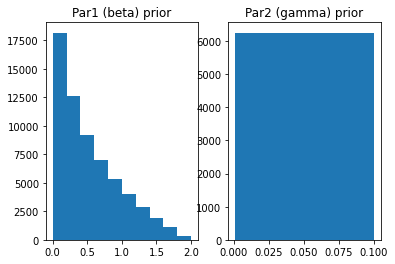

In [50]:
import grid_functions
importlib.reload(grid_functions)
from grid_functions import *

# BSI_vector + BSI_max_t + BSI_max
visualize_results("res/sim_res/obs_NORM_A_I0_2023-09-14_09-06-36", 0.5)

Results to visualize: res/sim_res/obs_NORM_A_I0_2023-09-13_14-16-48_BSI_vector_BSI_max_t/sim_params.txt
Year
2004    3.895481e-06
2005    3.949891e-10
2006    1.263574e-05
2007    4.214390e-06
2008    1.053623e-05
2009    5.791327e-06
2010    1.535184e-05
2011    8.640565e-06
2012    2.363202e-05
2013    3.185117e-05
2014    3.004447e-05
2015    1.012509e-05
2016    2.025119e-05
2017    2.130096e-05
Name: A, dtype: float64


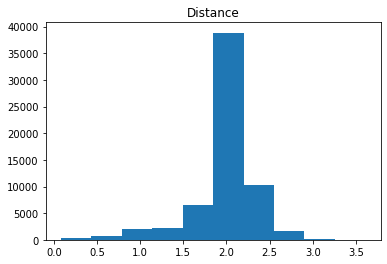

Beta mean: 0.024031277854402566
Gamma mean: 0.015743183259353203
R = mean(beta/gamma): 1.8788473818719857
R = median(beta/gamma): 1.543865140562249


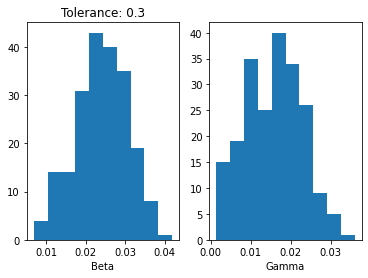

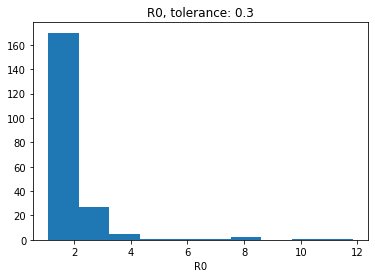

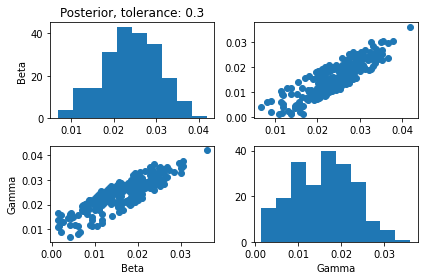

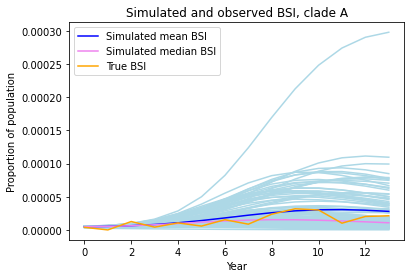

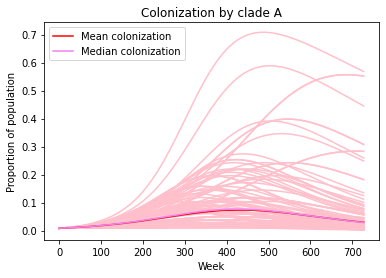

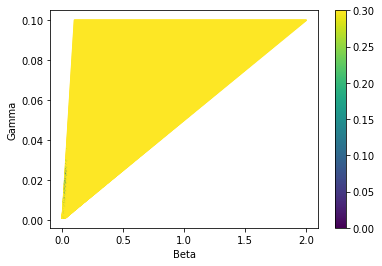

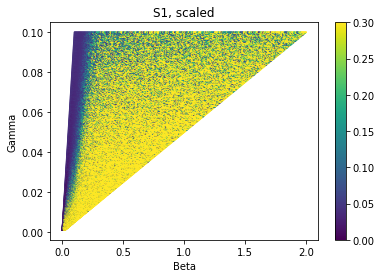

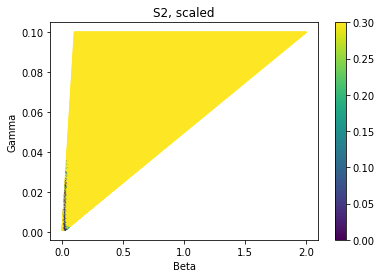

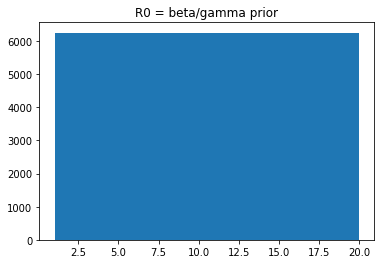

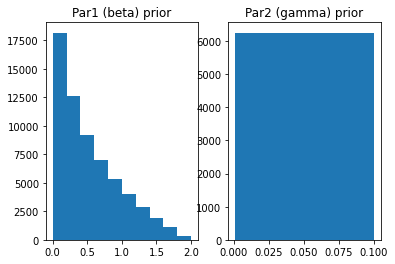

In [51]:
import grid_functions
importlib.reload(grid_functions)
from grid_functions import *

# BSI_vector + BSI_max_t
visualize_results("res/sim_res/obs_NORM_A_I0_2023-09-13_14-16-48_BSI_vector_BSI_max_t", 0.3)

In [14]:
# Load functions and data
import importlib
import numpy as np
import matplotlib.pyplot as plt

from cluster.scripts.BSI_functions import *
from cluster.scripts.SIR_functions import *
from cluster.scripts.load_data import *


Beta: 0.145, gamma: 0.026
R0: 5.576923076923077


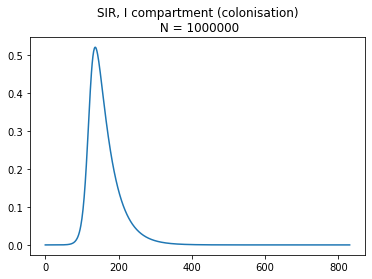

In [4]:
par1 = 0.145
par2 = 0.026
print(f"Beta: {par1}, gamma: {par2}")
print(f"R0: {par1/par2}")

nt = 16*52
N = 1000000

sir = SIR(par1, par2, nt, N, reparam = False, batch_size=1, random_state = None)
# Plot the result:
plt.plot(sir[1][0]) # 1 = I compartment, 0 = first batch
plt.title(f"SIR, I compartment (colonisation)\n N = {N}")
plt.show()

[3.89548110e-06 3.94989077e-10 1.26357430e-05 4.21438992e-06
 1.05362331e-05 5.79132651e-06 1.53518358e-05 8.64056533e-06
 2.36320218e-05 3.18511701e-05 3.00444681e-05 1.01250923e-05
 2.02511905e-05 2.13009564e-05]
[[2.32140498e-11 9.35654373e-11 3.77062148e-10 1.51858912e-09
  6.10071914e-09 2.42648931e-08 9.28186686e-08 3.08927293e-07
  7.00664380e-07 8.29434506e-07 5.29380539e-07 2.37441681e-07
  9.19773635e-08 3.37505631e-08]]


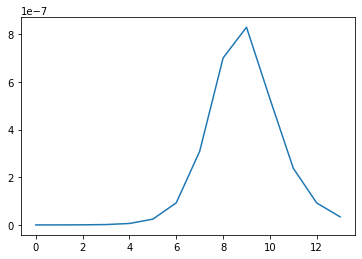

In [92]:
# Apply a uniform filter with convolution:

# Simulated bsi:
clade = "A"
obs_data = "NORM"
n_weeks = 14*52
pop_size = 1000000
is_prop = True
is_agg = True

# These are the mean values for beta and gamma when fitting the model to observed data:
true_par1 = 0.0740571043023658
true_par2 = 0.046887883517877184

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":1, "theta_bsi":0.00002/52, "include_I0": False}
bsi_sim = SIR_and_BSI_simulator(true_par1, true_par2, nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)
bsi_obs = get_incidence_data("data/NORM_incidence.csv", clade = clade, is_prop = is_prop, n_incidence_pop = pop_size)
print(np.array(bsi_obs))
print(bsi_sim)
plt.plot(bsi_sim[0])
#plt.plot(np.array(bsi_obs))
plt.show()

In [146]:
0.00002/52

3.8461538461538463e-07

[2.32140498e-11 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
[2.32140498e-11 3.72843273e-11 1.05239891e-10 3.87909737e-10
 1.53047162e-09 6.07735592e-09 2.34256184e-08 8.05259533e-08
 2.04553639e-07 3.29529812e-07 3.69499957e-07 3.43088302e-07
 2.92866114e-07 2.41043004e-07]


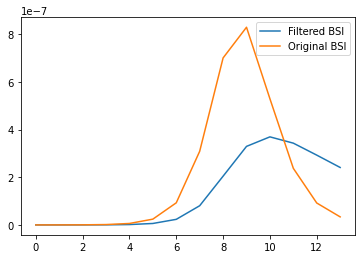

In [179]:
l = 30


# Convolution
x = bsi_sim[0]
alpha = 0.2 # if alpha = 1, then we get an identical sequence. If alpha is decreased, the peak moves forwards and is lowered too.
bsi_filtered = np.zeros(len(x))
bsi_filtered[0] = bsi_sim[0][0] # initialize at the first value of the sequence
print(bsi_filtered)
for i in range(1, len(x)):
    bsi_filtered[i] = alpha*x[i] + (1-alpha)*bsi_filtered[i-1] # This is exponential smoothing. Is this what we want?
    
#bsi_filtered = np.convolve(exp_filter, bsi_sim[0])
print(bsi_filtered)
plt.plot(bsi_filtered, label = "Filtered BSI")
plt.plot(x, label = "Original BSI")
plt.legend()
plt.show()

In [157]:
print(bsi_sim.shape)
len(bsi_sim)

(1, 14)


1

In [151]:
bsi_sim

array([[2.32140498e-11, 9.35654373e-11, 3.77062148e-10, 1.51858912e-09,
        6.10071914e-09, 2.42648931e-08, 9.28186686e-08, 3.08927293e-07,
        7.00664380e-07, 8.29434506e-07, 5.29380539e-07, 2.37441681e-07,
        9.19773635e-08, 3.37505631e-08]])

In [ ]:
def exp_col_model(I, t, alpha):
    # This function can be used instead of SIR model for colonization.
    
    
    
    pass


## Understanding convolution

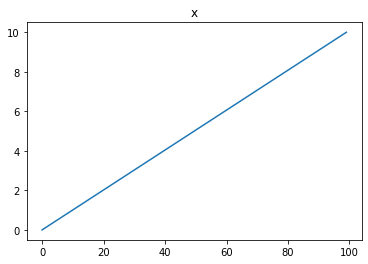

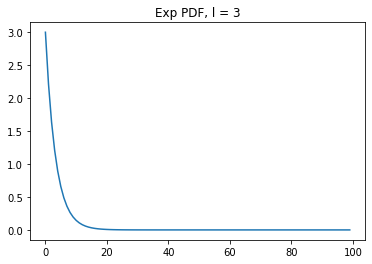

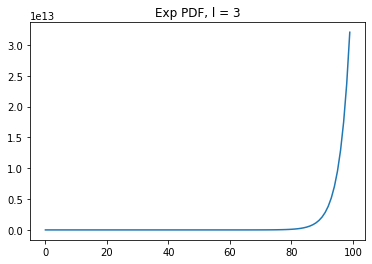

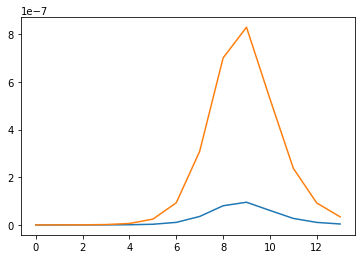

In [142]:

x = np.linspace(0, 10, 100)
l = 3

plt.plot(x)
plt.title("x")
plt.show()

def exp_pdf(l, x):
    return l*np.exp(-l*x)

# Filter
plt.plot(exp_pdf(l, x))
plt.title(f"Exp PDF, l = {l}")
plt.show()


# Flipped filter
plt.plot(exp_pdf(l, -x))
plt.title(f"Exp PDF, l = {l}")
plt.show()

filtered = np.zeros(len(bsi_sim[0]))
exp_filter = exp_pdf(l, x)

for i in range(0, len(filtered)):
    for j in range(0, len(exp_filter)):
        filtered[i] += bsi_sim[0][i]*exp_filter[i - j + len(bsi_sim[0])] # this just smooths the distribution.
    filtered[i] /= len(exp_filter)

plt.plot(filtered)
plt.plot(bsi_sim[0])
#plt.plot(np.convolve(bsi_sim[0], exp_filter))
plt.show()


# ???

In [141]:
def list_convolve(arr1, arr2):
    # TODO: implement convolution of two lists of arbitrary length
    
    conv = np.zeros(len(arr1) + len(arr2) - 1)
    
    for k in range(0, len(conv)):
        pass 


list_convolve([1,2,3], [4,5,6])

1
2
3
